# CH2 Waveform Analysis
Oscilloscope data from `Newfile2_2.csv`  
- **Channel**: CH2  
- **Start time**: −70 µs  
- **Sample rate**: 1 GS/s (1 ns increment)  
- **Samples**: ~140,000

In [11]:
import csv
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy import signal

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.grid': True,
    'grid.linestyle': '--',
    'grid.alpha': 0.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

## 1. Load data

In [12]:
CSV_FILE = "Newfile2.csv"
START_S  = -7e-5   # seconds
INC_S    =  1e-9   # 1 ns per sample

sequences, volts = [], []
with open(CSV_FILE, newline="") as f:
    for row in csv.reader(f):
        if len(row) < 2:
            continue
        try:
            sequences.append(int(row[0]))
            volts.append(float(row[1]))
        except ValueError:
            pass

seq      = np.array(sequences)
volts    = np.array(volts)
time_us  = (START_S + seq * INC_S) * 1e6   # µs

print(f"Samples loaded : {len(volts):,}")
print(f"Time range     : {time_us[0]:.2f} µs  →  {time_us[-1]:.2f} µs")
print(f"Voltage range  : {volts.min():.3f} V  →  {volts.max():.3f} V")
print(f"Mean / Std     : {volts.mean():.3f} V  /  {volts.std():.3f} V")

Samples loaded : 140,000
Time range     : -70.00 µs  →  70.00 µs
Voltage range  : -0.800 V  →  12.800 V
Mean / Std     : 5.483 V  /  5.969 V


## 2. Full waveform overview

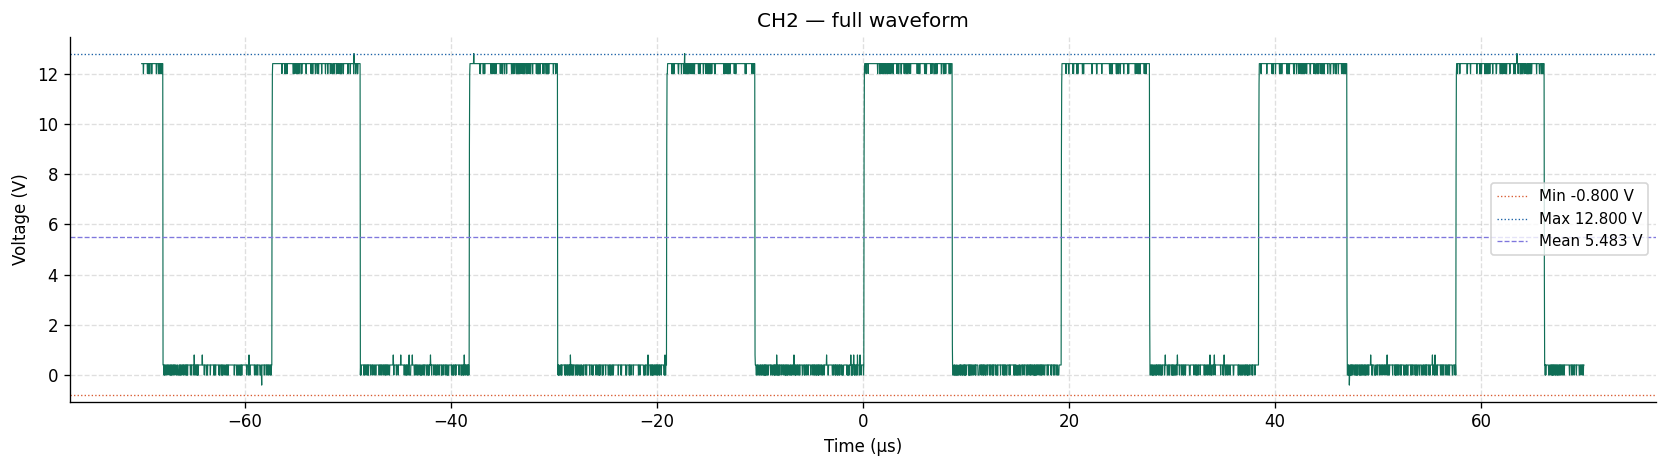

In [13]:
# Downsample to ~5000 pts for a fast overview
N = max(1, len(time_us) // 5000)
t_plot = time_us[::N]
v_plot = volts[::N]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_plot, v_plot, lw=0.7, color='#0F6E56', rasterized=True)
ax.axhline(volts.min(), color='#D85A30', lw=0.8, ls=':', label=f'Min {volts.min():.3f} V')
ax.axhline(volts.max(), color='#185FA5', lw=0.8, ls=':', label=f'Max {volts.max():.3f} V')
ax.axhline(volts.mean(), color='#7F77DD', lw=0.8, ls='--', label=f'Mean {volts.mean():.3f} V')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Voltage (V)')
ax.set_title('CH2 — full waveform')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 3. Voltage distribution

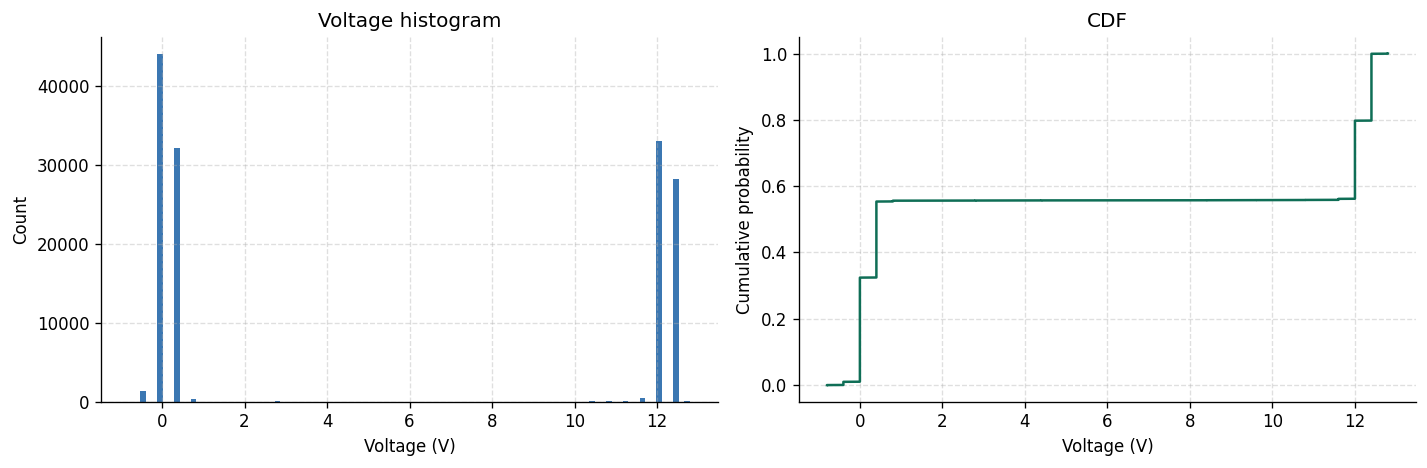

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram
ax = axes[0]
ax.hist(volts, bins=100, color='#185FA5', edgecolor='none', alpha=0.85)
ax.set_xlabel('Voltage (V)')
ax.set_ylabel('Count')
ax.set_title('Voltage histogram')

# CDF
ax2 = axes[1]
sorted_v = np.sort(volts)
cdf = np.arange(1, len(sorted_v) + 1) / len(sorted_v)
ax2.plot(sorted_v, cdf, color='#0F6E56', lw=1.5)
ax2.set_xlabel('Voltage (V)')
ax2.set_ylabel('Cumulative probability')
ax2.set_title('CDF')

plt.tight_layout()
plt.show()

## 4. Zoom into a time window
Edit `T_START` and `T_END` (in µs) to inspect any region.

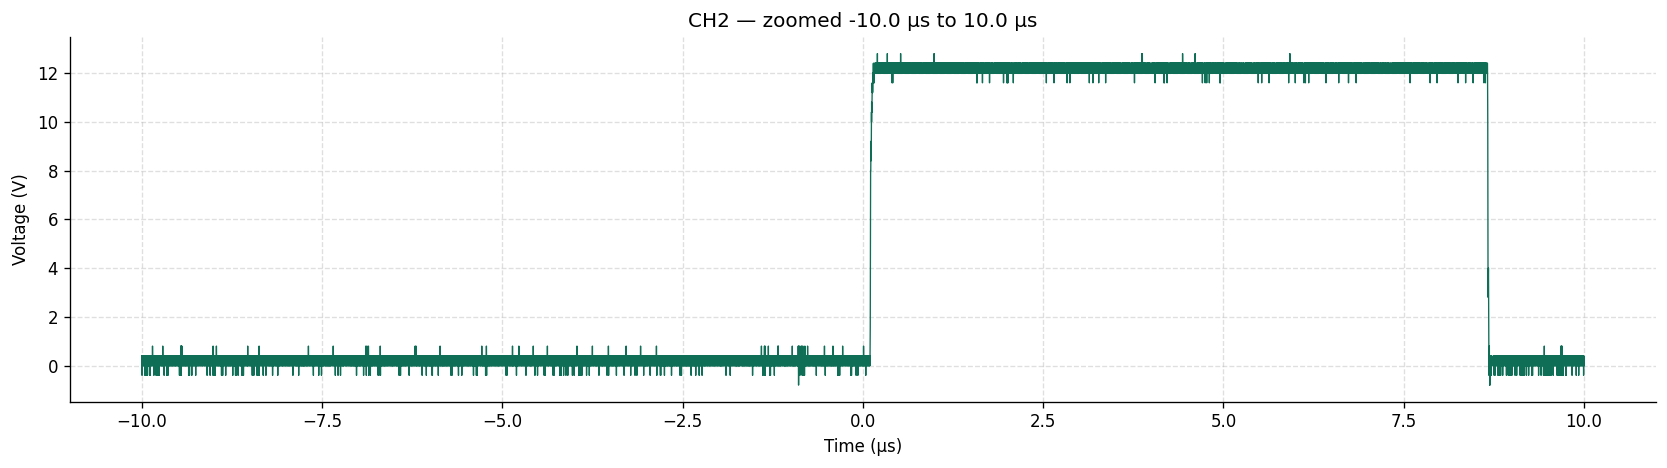

Points in window : 20,000
Min / Max        : -0.800 V / 12.800 V


In [15]:
T_START = -10.0   # µs
T_END   =  10.0   # µs

mask = (time_us >= T_START) & (time_us <= T_END)
t_win = time_us[mask]
v_win = volts[mask]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_win, v_win, lw=0.8, color='#0F6E56')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Voltage (V)')
ax.set_title(f'CH2 — zoomed {T_START} µs to {T_END} µs')
plt.tight_layout()
plt.show()

print(f"Points in window : {mask.sum():,}")
print(f"Min / Max        : {v_win.min():.3f} V / {v_win.max():.3f} V")

## 5. Edge / transition detection
Finds rising and falling edges using a threshold midpoint.

Threshold used : 6.000 V
Rising edges   : 7
Falling edges  : 8


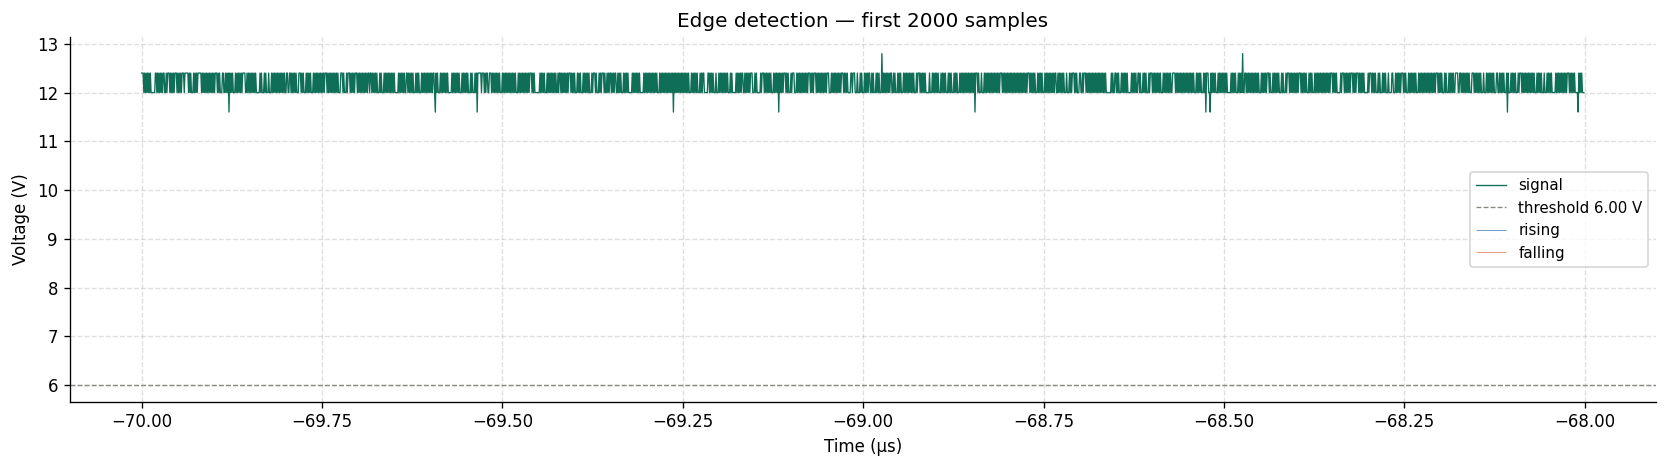

In [16]:
# Threshold at midpoint between the two dominant voltage levels
threshold = (volts.min() + volts.max()) / 2
binary = (volts >= threshold).astype(int)
diff   = np.diff(binary)

rising_idx  = np.where(diff ==  1)[0]
falling_idx = np.where(diff == -1)[0]

print(f"Threshold used : {threshold:.3f} V")
print(f"Rising edges   : {len(rising_idx):,}")
print(f"Falling edges  : {len(falling_idx):,}")

# Show first ~2000 pts with detected edges
SHOW = 2000
r_show = rising_idx[rising_idx < SHOW]
f_show = falling_idx[falling_idx < SHOW]

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(time_us[:SHOW], volts[:SHOW], lw=0.8, color='#0F6E56', label='signal')
ax.axhline(threshold, color='#888780', lw=0.8, ls='--', label=f'threshold {threshold:.2f} V')
ax.vlines(time_us[r_show], volts.min(), volts.max(), color='#185FA5', lw=0.6, alpha=0.6, label='rising')
ax.vlines(time_us[f_show], volts.min(), volts.max(), color='#D85A30', lw=0.6, alpha=0.6, label='falling')
ax.set_xlabel('Time (µs)')
ax.set_ylabel('Voltage (V)')
ax.set_title('Edge detection — first 2000 samples')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 6. Power spectral density (FFT)
Uses Welch's method on the full signal.

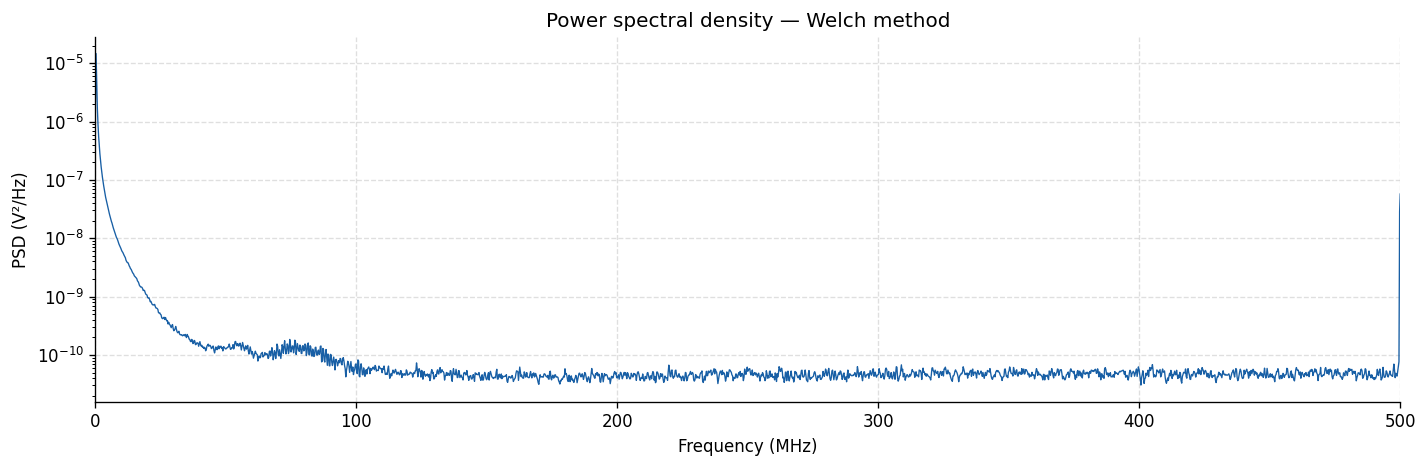

In [17]:
fs = 1 / INC_S   # 1 GHz sample rate

freqs, psd = signal.welch(volts, fs=fs, nperseg=4096)
freqs_mhz  = freqs / 1e6

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freqs_mhz, psd, lw=0.8, color='#185FA5')
ax.set_xlabel('Frequency (MHz)')
ax.set_ylabel('PSD (V²/Hz)')
ax.set_title('Power spectral density — Welch method')
ax.set_xlim(0, freqs_mhz[-1])
plt.tight_layout()
plt.show()

## 7. Save figure

Saved waveform_analysis.png


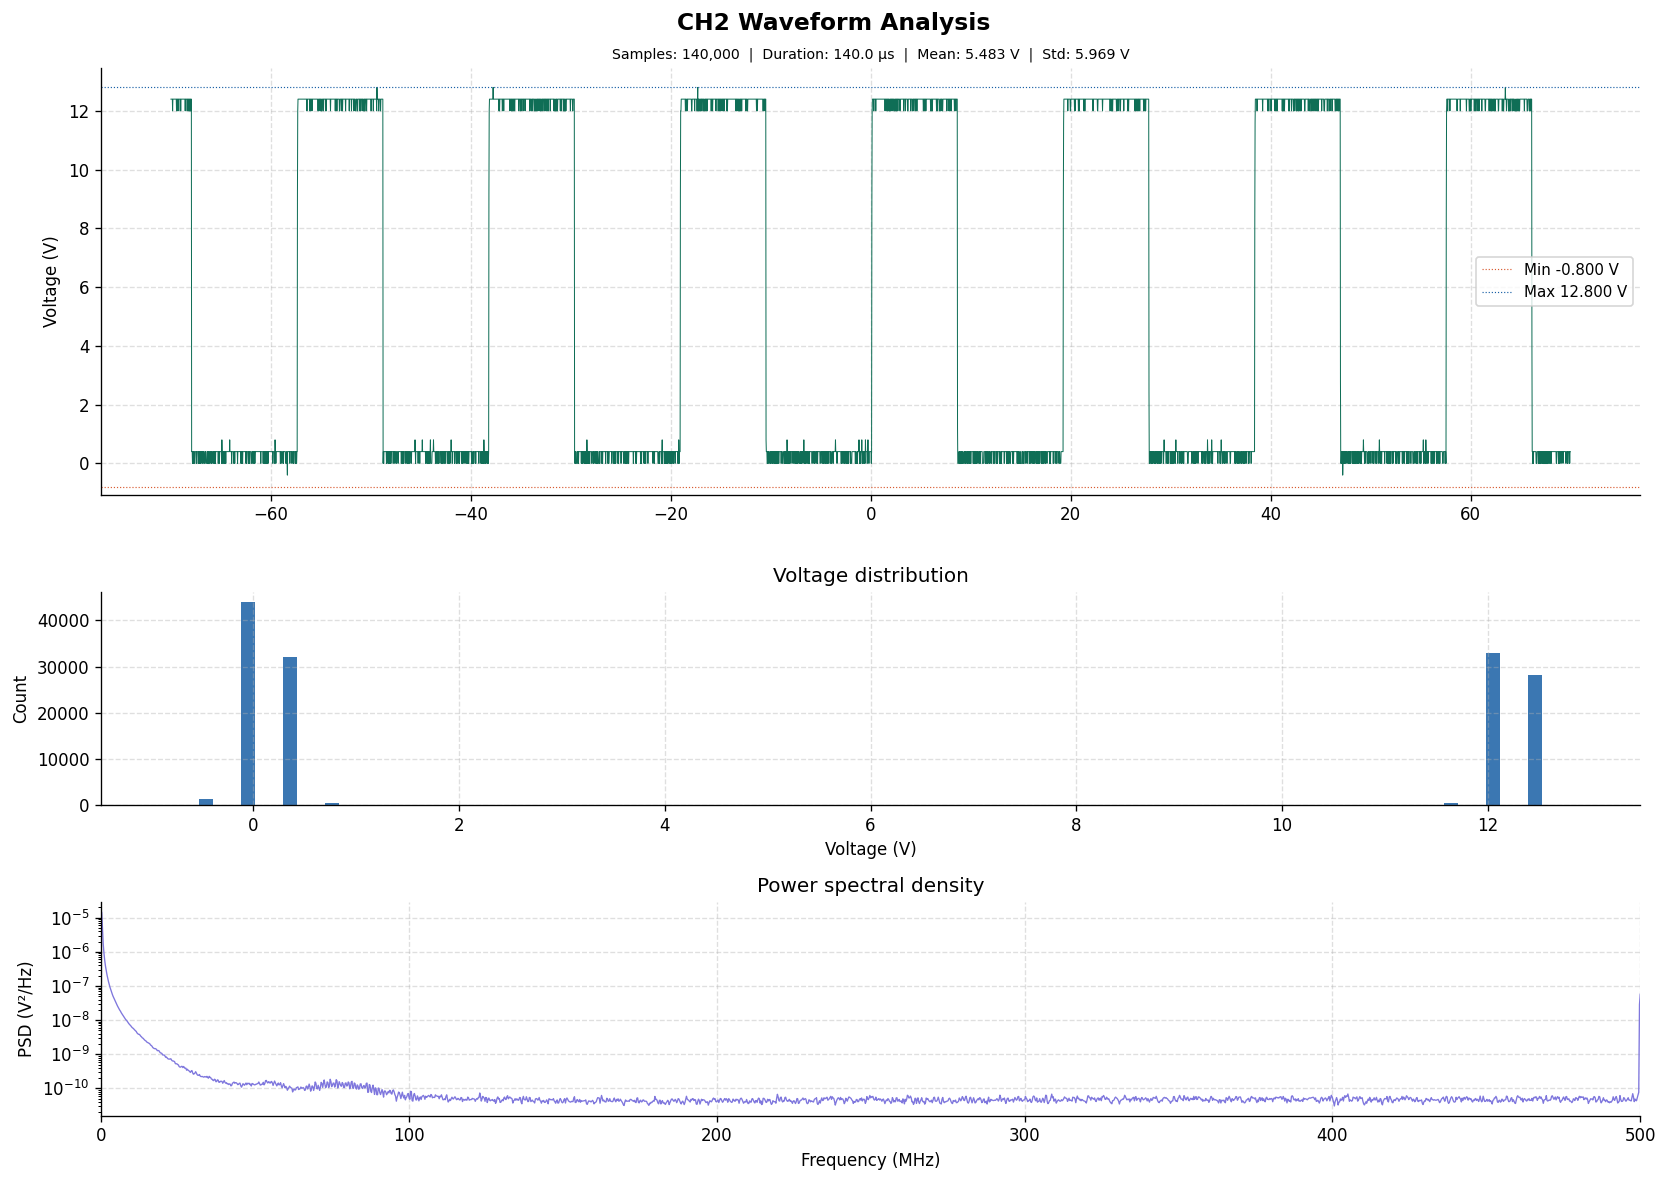

In [18]:
N = max(1, len(time_us) // 5000)

fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                          gridspec_kw={'height_ratios': [3, 1.5, 1.5]})
fig.suptitle('CH2 Waveform Analysis', fontsize=14, fontweight='bold')

# Waveform
axes[0].plot(time_us[::N], volts[::N], lw=0.6, color='#0F6E56', rasterized=True)
axes[0].axhline(volts.min(), color='#D85A30', lw=0.7, ls=':', label=f'Min {volts.min():.3f} V')
axes[0].axhline(volts.max(), color='#185FA5', lw=0.7, ls=':', label=f'Max {volts.max():.3f} V')
axes[0].set_ylabel('Voltage (V)')
axes[0].legend(fontsize=9)
axes[0].set_title(f'Samples: {len(volts):,}  |  Duration: {time_us[-1]-time_us[0]:.1f} µs  |  Mean: {volts.mean():.3f} V  |  Std: {volts.std():.3f} V', fontsize=8.5)

# Histogram
axes[1].hist(volts, bins=100, color='#185FA5', edgecolor='none', alpha=0.85)
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Voltage (V)')
axes[1].set_title('Voltage distribution')

# PSD
axes[2].semilogy(freqs_mhz, psd, lw=0.8, color='#7F77DD')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('PSD (V²/Hz)')
axes[2].set_title('Power spectral density')
axes[2].set_xlim(0, 500)

plt.tight_layout()
plt.savefig('waveform_analysis.png', dpi=150, bbox_inches='tight')
print('Saved waveform_analysis.png')
plt.show()